# Batch-wise causarray Analysis — Replogle-E-K562

This tutorial runs the **batch fitting workflow** of `causarray` on a subset of the
Replogle et al. 2022 genome-wide CRISPRi screen in K562 cells
([Cell 2022](https://doi.org/10.1016/j.cell.2022.05.013)), then compares the result
with a marginal Wilcoxon test and inspects the propensity model behind it.

**Data.** The full screen has 309,915 cells × 8,563 genes and 2,021 perturbations.
`prep_tutorial_data.py` keeps the 200 most abundant perturbations plus 2,000
non-targeting control cells, giving **79,865 cells**.

**Why batch fitting?** Fitting `fit_gcate` on all cells at once means a design with
200 treatment columns, which is both numerically difficult and memory-intensive.
`gcate_lfc_batch` instead pairs each batch of 15 perturbations with a fixed control
pool, so peak memory depends on one batch rather than on the total perturbation count.

```
replogle_subset.h5ad
  |-- prep_causarray_data  ->  Y, A, X, X_A
       |-- gcate_lfc_batch ->  df_res  (tau, std, stat, pvalue, padj per gene × pert)
            |-- volcano, discovery counts, Wilcoxon comparison, propensity diagnostics
```

> Sections 5.4 and 5.5 additionally require the optional `crispyx` package and the
> local cache written by `cache_propensity_batch.py`.

In [1]:
import sys
sys.path.insert(0, '../../..')

import time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc

from causarray import prep_causarray_data, gcate_lfc_batch, align_test_mask
from causarray.gcate import plot_r

import causarray
print('causarray version:', causarray.__version__)


causarray version: 0.0.9


## 1. Load data

`prep_tutorial_data.py` built the subset: the 200 perturbations with the most cells,
plus 2,000 `non-targeting` control cells.

In [2]:
adata = sc.read_h5ad('replogle_subset.h5ad')
print(adata)

CTRL_LABEL = adata.uns['ctrl_label']   # 'non-targeting'
PERT_COL   = adata.uns['pert_col']     # 'gene'

vc = adata.obs[PERT_COL].value_counts()
print(f'\nCtrl cells  : {vc[CTRL_LABEL]}')
print(f'Pert cells  : {vc.drop(CTRL_LABEL).sum():,}  across {len(vc) - 1} perturbations')
print(f'Cells/pert  : median {vc.drop(CTRL_LABEL).median():.0f}, '
      f'range {vc.drop(CTRL_LABEL).min()}-{vc.drop(CTRL_LABEL).max()}')


AnnData object with n_obs × n_vars = 79865 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    uns: 'ctrl_label', 'pert_col'

Ctrl cells  : 2000
Pert cells  : 77,865  across 200 perturbations
Cells/pert  : median 346, range 273-1996


## 2. Prepare causarray inputs

`prep_causarray_data` caps every count at the 99.9th percentile of the per-gene maxima,
prepends an intercept column, and appends a standardized log library size to the
propensity design `X_A`.

In [3]:
Y_raw = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
Y = pd.DataFrame(Y_raw, columns=adata.var_names.tolist())
del Y_raw

A = (pd.get_dummies(adata.obs[PERT_COL].astype(str), drop_first=False)
       .drop(columns=[CTRL_LABEL]))

Y, A, X, X_A = prep_causarray_data(Y, A)

print(f'Y : {Y.shape}  (cells x genes)')
print(f'A : {A.shape}  (cells x perturbations)')
print(f'X : {X.shape}  X_A : {X_A.shape}')


Y : (79865, 8563)  (cells x genes)
A : (79865, 200)  (cells x perturbations)
X : (79865, 1)  X_A : (79865, 2)


## 3. Number of latent factors

`r` is selected by the JIC criterion from `estimate_r`. Pre-computed values are loaded
from `replogle-r.csv`; re-run `estimate_r_replogle.py` to reproduce them.

> **Why estimate r on control cells?**
> `estimate_r` fits GCATE internally, which is expensive at full scale (79,865 cells).
> The latent factors capture confounding variation that is already present in the
> baseline transcriptome, so a control-heavy subsample is far cheaper and selects
> essentially the same `r`. Pass `max_cells` to reproduce this directly — control cells
> are prioritized automatically:
> ```python
> df_r = estimate_r(Y, X, A, r_values, family='nb', max_cells=6000)
> ```

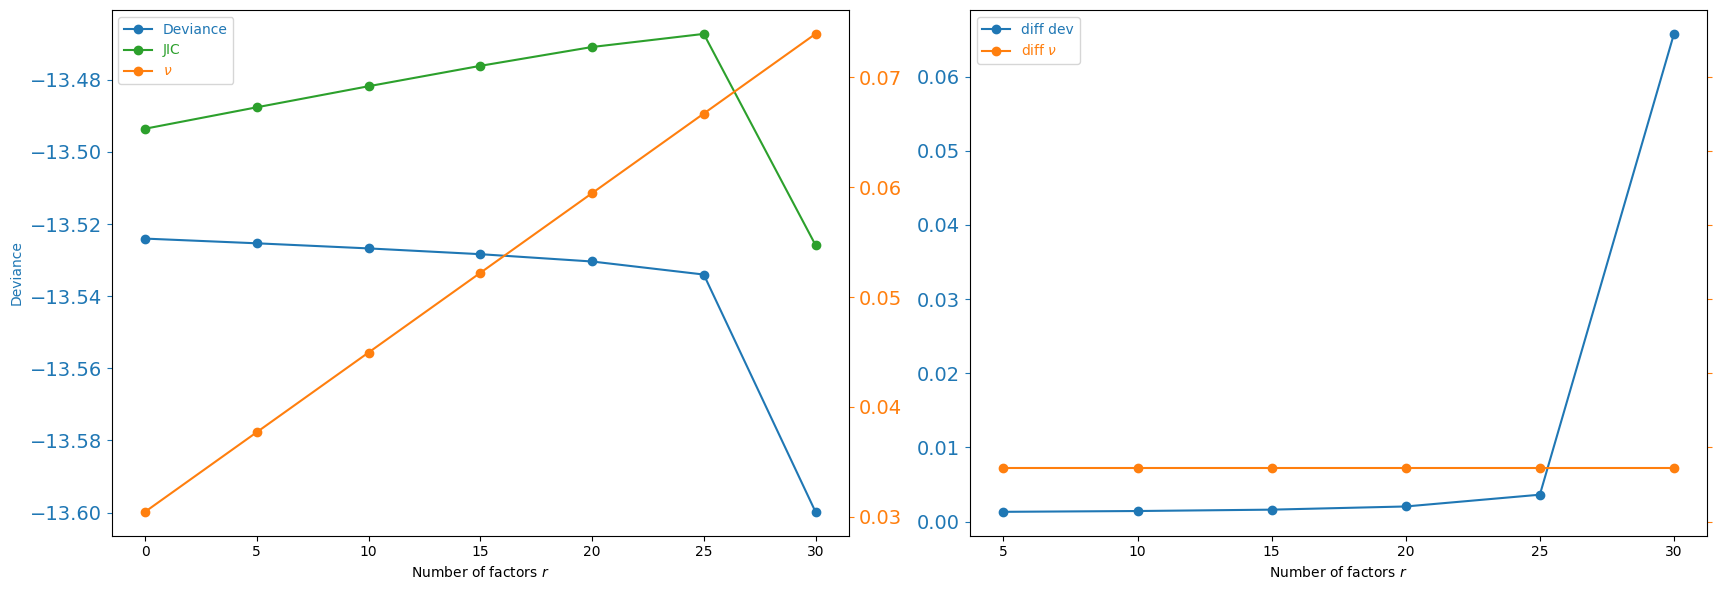


Selected r = 30  (min JIC)
 r   deviance       nu        JIC
 0 -13.524045 0.030448 -13.493596
 5 -13.525350 0.037698 -13.487652
10 -13.526765 0.044947 -13.481817
15 -13.528364 0.052197 -13.476167
20 -13.530392 0.059447 -13.470945
25 -13.534008 0.066696 -13.467311
30 -13.599773 0.073946 -13.525827


In [4]:
df_r = pd.read_csv('replogle-r.csv')
fig = plot_r(df_r)
plt.tight_layout()
plt.show()

best_r = int(df_r.loc[df_r['JIC'].idxmin(), 'r'])
print(f'\nSelected r = {best_r}  (min JIC)')
print(df_r.to_string(index=False))


## 4. Batch fitting with `gcate_lfc_batch`

| Parameter | Value | Effect |
|-----------|-------|--------|
| `batch_size` | 15 | ~15 perturbations per GCATE call |
| `max_cells` | 2000 | ≤ 2000 perturbed cells per batch (controls added on top) |
| `n_ctrl` | 2000 | Fixed control subsample shared across all batches |
| `usevar` | `'unequal'` | Welch treatment/control variance for inference |
| `cache_path` | `'replogle_results.h5'` | Resume from disk if interrupted |

With 200 perturbations and `batch_size=15`, `gcate_lfc_batch` uses
`n_batches = ceil(200 / 15) = 14` and splits the remainder evenly with
`numpy.array_split`, giving **4 batches of 15 and 10 batches of 14** rather than a
tiny tail batch. Each batch holds at most 2,000 control + 2,000 perturbed cells.

In [5]:
R = best_r

t0 = time.perf_counter()
df_res = gcate_lfc_batch(
    Y, X, A, R,
    W_A=X_A,
    batch_size=15,
    max_cells=2000,
    n_ctrl=2000,
    family='nb',
    lfc_kwargs=dict(usevar='unequal'),
    cache_path='replogle_results.h5',
    random_state=0,
    verbose=True,
    gcate_kwargs=dict(
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
    ),
)
t_total = time.perf_counter() - t0

print(f'\nTotal wall time: {t_total/60:.1f} min')
print(f'Result shape   : {df_res.shape}')
df_res.head()


[gcate_lfc_batch] Resuming: 14 batches already cached in 'replogle_results.h5'
'Pre-estimating dispersion on ctrl cell subsample...'


GCATE batches:   0%|          | 0/14 [00:00<?, ?batch/s]

GCATE batches: 100%|██████████| 14/14 [00:00<00:00, 134679.49batch/s]


Total wall time: 0.1 min
Result shape   : (1712600, 16)


,gene_names,tau,std,log2fc,log2fc_se,stat,rej,pvalue,padj,pvalue_emp_null_adj,padj_emp_null_adj,mean_control,mean_treated,estimable,trt,batch
0,LINC01409,0.000000,inf,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.072352,0.078497,True,AATF,0
1,LINC01128,-0.130575,2.677546,-0.188380,3.862882,-0.048767,0.0,0.961208,0.972917,0.667758,0.999905,0.156995,0.137778,True,AATF,0
2,NOC2L,0.017141,0.247328,0.024729,0.356819,0.069305,0.0,0.944891,0.972917,0.826848,0.999905,0.824667,0.838924,True,AATF,0
3,KLHL17,0.000000,inf,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.077686,0.084759,True,AATF,0
4,HES4,0.000000,inf,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.137674,0.134297,True,AATF,0


## 5. Results

### 5.1 Discovery summary


In [6]:
FDR = 0.05
sig = df_res[df_res['padj'] < FDR]

print(f'Significant (padj < {FDR}): {len(sig):,} gene x pert pairs')
print(f'  Perturbations with >= 1 hit: {sig["trt"].nunique()}')
print(f'  Unique genes affected      : {sig["gene_names"].nunique():,}')

disc_per_pert = sig.groupby('trt').size().sort_values(ascending=False)
print(f'\nTop-10 perts by discovery count:')
print(disc_per_pert.head(10).to_string())


Significant (padj < 0.05): 20,450 gene x pert pairs
  Perturbations with >= 1 hit: 162
  Unique genes affected      : 3,831

Top-10 perts by discovery count:
trt
SUPT5H    1878
SUPT6H    1340
SFPQ       854
CSE1L      740
DDX47      561
HSPA9      547
PSMD6      509
NCBP2      496
TSR2       452
MED12      420


### 5.2 Volcano plot (all perturbations combined)


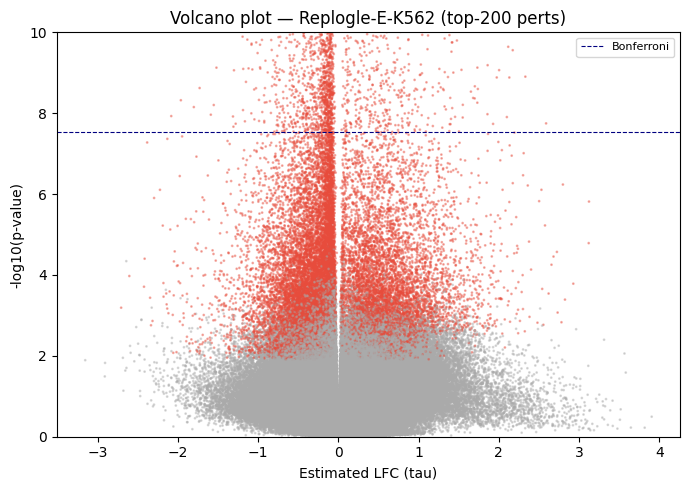

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = np.where(df_res['padj'] < FDR, '#e74c3c', '#aaaaaa')
ax.scatter(
    df_res['tau'], -np.log10(df_res['pvalue'].clip(1e-300)),
    c=colors, s=1, alpha=0.4, rasterized=True,
)
ax.axhline(-np.log10(0.05 / len(df_res)), color='navy', lw=0.8, ls='--',
           label='Bonferroni')
ax.set_ylim(0, 10)
ax.set_xlabel('Estimated LFC (tau)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — Replogle-E-K562 (top-200 perts)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Discovery count per perturbation

Each bar is the number of significant genes (BH-adjusted *p* < 0.05) for one
perturbation. Because causarray deconfounds shared latent variation before testing,
the wide variation mostly reflects real differences in perturbation strength rather
than technical artefacts.

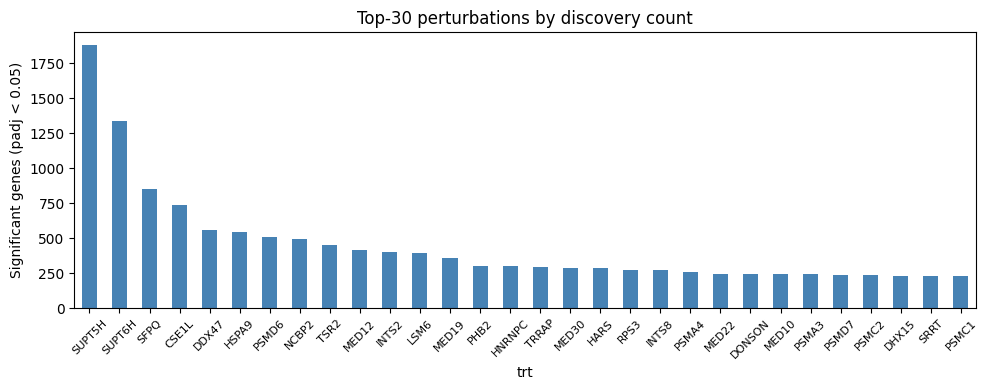

In [8]:
top_n = 30
top_disc = disc_per_pert.head(top_n)

fig, ax = plt.subplots(figsize=(10, 4))
top_disc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_ylabel(f'Significant genes (padj < {FDR})')
ax.set_title(f'Top-{top_n} perturbations by discovery count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()


### 5.4 Comparison with a marginal Wilcoxon test

As a reference point, each perturbation is also compared with the pooled non-targeting
controls using a Wilcoxon rank-sum test on library-size-normalized, log1p counts
(via the optional `crispyx` package). Both methods are summarized at BH-adjusted
*p* < 0.05.

Wilcoxon is *marginal*: unlike causarray it adjusts for neither the observed covariates
nor the estimated latent factors. Gaps in discovery counts can therefore reflect
confounding, model assumptions, filtering, or power, and do not by themselves mark
discoveries as true or false.

In [9]:
import crispyx

# Wilcoxon is applied to normalized, log-transformed counts, following the
# same convention as the Adamson tutorial.
norm_path = Path('replogle_subset_norm.h5ad')
if not norm_path.exists():
    crispyx.normalize_total_log1p(
        'replogle_subset.h5ad', output_path=str(norm_path), verbose=False
    )
wc_result = crispyx.wilcoxon_test(
    str(norm_path),
    perturbation_column=PERT_COL,
    control_label=CTRL_LABEL,
    verbose=False,
)

wc_count_map = {
    str(pert): int((np.asarray(wc_result[pert].pvalue_adj) < FDR).sum())
    for pert in wc_result.groups
}
all_perts = pd.Index(A.columns.astype(str), name='Perturbation')
comparison_counts = pd.DataFrame(index=all_perts)
comparison_counts['causarray'] = (
    disc_per_pert.rename(index=str).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts['Wilcoxon'] = (
    pd.Series(wc_count_map).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts = comparison_counts.sort_values(
    ['Wilcoxon', 'causarray'], ascending=False
)

print(f'causarray: {comparison_counts["causarray"].sum():,} significant pairs')
print(f'Wilcoxon : {comparison_counts["Wilcoxon"].sum():,} significant pairs')
print('Median discoveries per perturbation: ' +
      f'causarray={comparison_counts["causarray"].median():.0f}, ' +
      f'Wilcoxon={comparison_counts["Wilcoxon"].median():.0f}')
display(comparison_counts.head(10))


causarray: 20,450 significant pairs
Wilcoxon : 393,099 significant pairs
Median discoveries per perturbation: causarray=24, Wilcoxon=1979


,causarray,Wilcoxon
Perturbation,,
SUPT5H,1878,6709
SUPT6H,1340,6384
MED12,420,5842
MED30,292,5333
INTS2,406,5307
HSPA9,547,5196
MED19,361,4923
DDX41,80,4777
PHB2,302,4661


#### Are the extra Wilcoxon hits biologically meaningful?

Across 8,563 genes, Wilcoxon reports 393,099 significant gene-perturbation pairs
(median 1,979 per perturbation) against causarray's 20,450 (median 24); for SUPT5H the
counts are 6,709 and 1,878. List size alone says nothing about quality, so we use
direction-specific Gene Ontology enrichment instead. SUPT5H encodes SPT5, a central
regulator of RNA polymerase II pausing and elongation, so a broad response is
biologically credible.

The two result matrices are first aligned on (perturbation, gene) labels, so that
batched row order is never mistaken for biological agreement.

In [10]:
wc_groups = pd.Index([str(group) for group in wc_result.groups], name='trt')
wc_genes = pd.Index(wc_result.genes.astype(str), name='gene_names')
wc_lfc = np.asarray(wc_result.logfoldchanges, dtype=float)
wc_padj = np.asarray(wc_result.pvalues_adj, dtype=float)
wc_pts_treated = np.asarray(wc_result.pts, dtype=float)
wc_pts_control = np.asarray(wc_result.pts_rest, dtype=float)

expected = pd.MultiIndex.from_product([wc_groups, wc_genes])
ca_indexed = (
    df_res.assign(
        trt=df_res['trt'].astype(str),
        gene_names=df_res['gene_names'].astype(str),
    ).set_index(['trt', 'gene_names'])
)
if ca_indexed.index.has_duplicates:
    raise ValueError('causarray contains duplicate perturbation-gene tests')
aligned_ca = ca_indexed.reindex(expected)
if aligned_ca['tau'].isna().all():
    raise ValueError('Wilcoxon and causarray results could not be aligned')

ca_lfc = (
    aligned_ca['tau'].to_numpy(dtype=float).reshape(wc_lfc.shape)
    / np.log(2.0)
)
ca_padj = aligned_ca['padj'].to_numpy(dtype=float).reshape(wc_lfc.shape)
ca_estimable = aligned_ca['estimable'].fillna(False).to_numpy().reshape(wc_lfc.shape)
wc_reject = wc_padj < FDR
ca_reject = ca_padj < FDR
del aligned_ca, ca_indexed, expected

print(f'Aligned {wc_lfc.size:,} perturbation-gene tests.')


Aligned 1,712,600 perturbation-gene tests.


#### SUPT5H Gene Ontology enrichment

Up- and down-regulated genes are tested separately, since pooling directions obscures
their biological meaning. The background is the 8,563 genes tested by both methods
rather than the whole genome. Enrichment power depends on list size, so term
*p*-values cannot certify one DE method as correct.

,DE_genes,significant_GO_BP_terms
Wilcoxon down,6163,0
Wilcoxon up,546,22
causarray down,1501,79
causarray up,377,0


,query,name,p_value,intersection_size,query_size
5,Wilcoxon up,cytoplasmic translation,4.640981e-30,66,510
15,Wilcoxon up,translation,8.293321e-15,90,510
16,Wilcoxon up,protein biosynthetic process,8.293321e-15,90,510
18,Wilcoxon up,proton transmembrane transport,1.983633e-11,36,510
26,Wilcoxon up,monoatomic cation transport,5.623571e-08,60,510
0,causarray down,translation,2.439314e-47,238,1441
1,causarray down,protein biosynthetic process,2.439314e-47,238,1441
2,causarray down,ribonucleoprotein complex biogenesis,6.807785e-42,197,1441
3,causarray down,cytoplasmic translation,6.828707e-36,111,1441
4,causarray down,ribosome biogenesis,8.173859e-33,142,1441


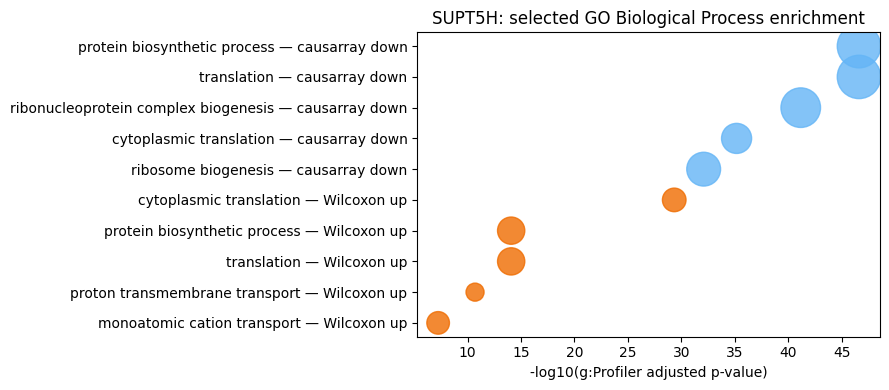

In [11]:
go_result_path = Path('replogle_supt5h_go_results.csv')
supt5h_i = wc_groups.get_loc('SUPT5H')
go_queries = {
    'causarray up': wc_genes[ca_reject[supt5h_i] & (ca_lfc[supt5h_i] > 0)].tolist(),
    'causarray down': wc_genes[ca_reject[supt5h_i] & (ca_lfc[supt5h_i] < 0)].tolist(),
    'Wilcoxon up': wc_genes[wc_reject[supt5h_i] & (wc_lfc[supt5h_i] > 0)].tolist(),
    'Wilcoxon down': wc_genes[wc_reject[supt5h_i] & (wc_lfc[supt5h_i] < 0)].tolist(),
}
if go_result_path.exists():
    go_results = pd.read_csv(go_result_path)
else:
    go_results = sc.queries.enrich(
        go_queries, org='hsapiens',
        gprofiler_kwargs={
            'sources': ['GO:BP'],
            'background': wc_genes.tolist(),
            'no_evidences': False,
        },
    )
    go_results.to_csv(go_result_path, index=False)

go_query_summary = pd.DataFrame({
    'DE_genes': {query: len(genes) for query, genes in go_queries.items()},
    'significant_GO_BP_terms': (
        go_results.loc[go_results['significant']].groupby('query').size()
    ),
}).fillna(0).astype(int)
display(go_query_summary)

go_top = (
    go_results.loc[go_results['significant'] & go_results['term_size'].between(20, 1000)]
    .sort_values(['query', 'p_value'])
    .groupby('query', group_keys=False).head(5)
)
display(go_top[['query', 'name', 'p_value', 'intersection_size', 'query_size']])

if not go_top.empty:
    plotted = go_top.sort_values('p_value', ascending=False).copy()
    plotted['label'] = plotted['name'] + ' — ' + plotted['query']
    colors = plotted['query'].map({
        'causarray up': '#1976d2', 'causarray down': '#64b5f6',
        'Wilcoxon up': '#ef6c00', 'Wilcoxon down': '#ffb74d',
    })
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plotted))))
    ax.scatter(
        -np.log10(plotted['p_value'].clip(1e-300)), plotted['label'],
        s=25 + 4 * plotted['intersection_size'], c=colors, alpha=0.8,
    )
    ax.set_xlabel('-log10(g:Profiler adjusted p-value)')
    ax.set_ylabel('')
    ax.set_title('SUPT5H: selected GO Biological Process enrichment')
    fig.tight_layout()
    plt.show()


In the cached analysis, the causarray down-regulated list is strongly enriched for
translation, ribosome biogenesis, and rRNA processing, and the smaller Wilcoxon
up-regulated list for cytoplasmic translation and mitochondrial energy production. The
very large Wilcoxon down-regulated list yields no significant GO Biological Process term
against this restricted background, which is a signature of list saturation rather than
absent biology. causarray thus gives a more selective list of coherent adjusted
responses, although enrichment alone cannot show that individual Wilcoxon-only
discoveries are false.

#### Effect-size agreement and extreme Wilcoxon effects

Marginal log2 fold changes grow very large when a gene is nearly absent in one arm,
where the value depends strongly on the pseudocount. The full-range panel exposes those
points; the zoomed panel makes agreement in the central range visible. Colors mark which
methods reject at the common 5% FDR threshold.

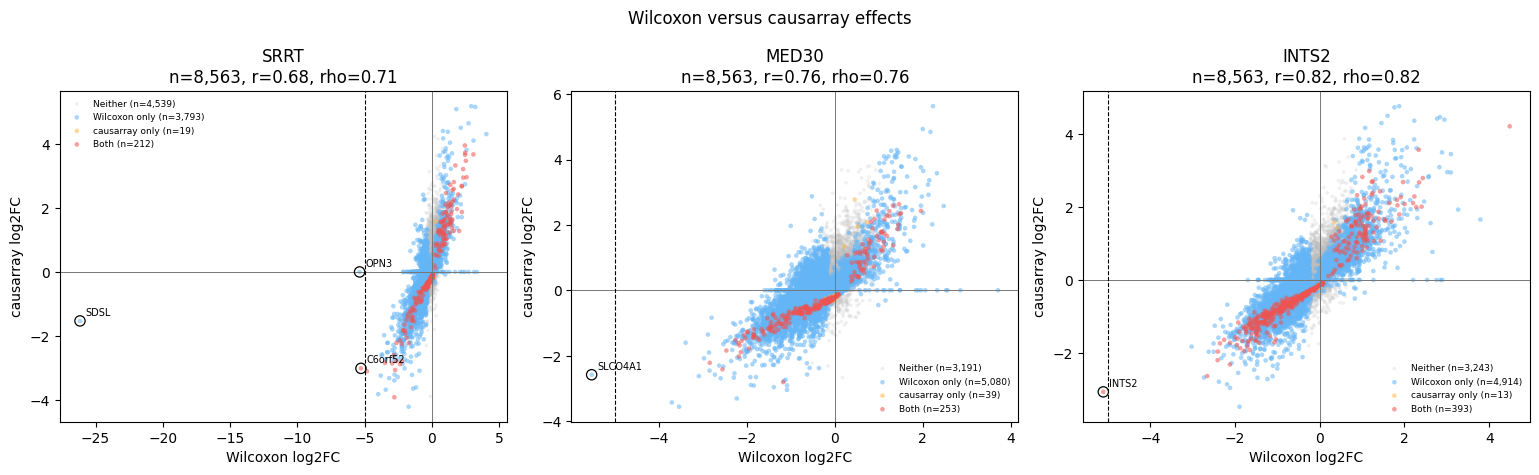

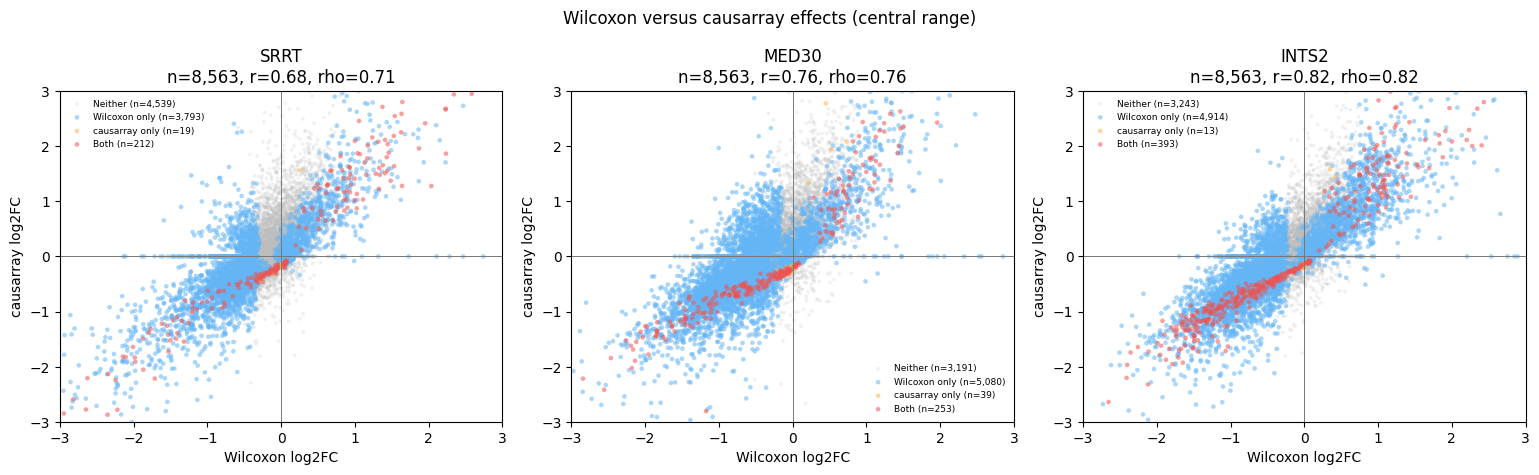

In [12]:
selected_perts = ['SRRT', 'MED30', 'INTS2']
category_colors = {
    'Neither': '#bdbdbd',
    'Wilcoxon only': '#64b5f6',
    'causarray only': '#ffb74d',
    'Both': '#ef5350',
}

def plot_lfc_comparison(limits=None):
    fig, axes = plt.subplots(1, len(selected_perts), figsize=(15.5, 4.8))
    for ax, perturbation in zip(axes, selected_perts):
        i = wc_groups.get_loc(perturbation)
        x, y = wc_lfc[i], ca_lfc[i]
        finite = np.isfinite(x) & np.isfinite(y)
        categories = np.select(
            [
                wc_reject[i] & ca_reject[i],
                wc_reject[i] & ~ca_reject[i],
                ~wc_reject[i] & ca_reject[i],
            ],
            ['Both', 'Wilcoxon only', 'causarray only'],
            default='Neither',
        )
        for category, color in category_colors.items():
            keep = finite & (categories == category)
            ax.scatter(
                x[keep], y[keep], s=7 if category == 'Neither' else 11,
                alpha=0.22 if category == 'Neither' else 0.55,
                color=color, edgecolors='none', rasterized=True,
                label=f'{category} (n={keep.sum():,})',
            )
        extreme = finite & (x < -5)
        if extreme.any():
            ax.scatter(
                x[extreme], y[extreme], s=55, facecolors='none',
                edgecolors='black', linewidths=0.9, zorder=5,
            )
            for gene, xv, yv in zip(wc_genes[extreme], x[extreme], y[extreme]):
                ax.annotate(gene, (xv, yv), xytext=(4, 4),
                            textcoords='offset points', fontsize=7)
        pearson = np.corrcoef(x[finite], y[finite])[0, 1]
        spearman = pd.Series(x[finite]).corr(pd.Series(y[finite]), method='spearman')
        ax.axhline(0, color='#777777', linewidth=0.7)
        ax.axvline(0, color='#777777', linewidth=0.7)
        ax.axvline(-5, color='black', linestyle='--', linewidth=0.8)
        if limits is not None:
            ax.set_xlim(limits)
            ax.set_ylim(limits)
        ax.set_title(
            f'{perturbation}\nn={finite.sum():,}, r={pearson:.2f}, rho={spearman:.2f}'
        )
        ax.set_xlabel('Wilcoxon log2FC')
        ax.set_ylabel('causarray log2FC')
        ax.legend(fontsize=6.5, frameon=False, loc='best')
    suffix = ' (central range)' if limits is not None else ''
    fig.suptitle('Wilcoxon versus causarray effects' + suffix)
    fig.tight_layout()
    return fig, axes

plot_lfc_comparison()
plt.show()
plot_lfc_comparison(limits=(-3, 3))
plt.show()


#### Tests with Wilcoxon log2FC below -5

Detection counts make the support in each arm explicit. Direct targets are flagged,
because strong depletion of the perturbed gene itself is biologically expected.

In [13]:
group_counts = adata.obs[PERT_COL].astype(str).value_counts()
treated_sizes = np.asarray([group_counts[group] for group in wc_groups])[:, None]
control_size = int(group_counts[CTRL_LABEL])
treated_detected = np.rint(wc_pts_treated * treated_sizes).astype(int)
control_detected = np.rint(wc_pts_control * control_size).astype(int)
extreme_positions = np.argwhere(wc_lfc < -5)

extreme_rows = []
for i, j in extreme_positions:
    if wc_reject[i, j] and ca_reject[i, j]:
        decision = 'Both'
    elif wc_reject[i, j]:
        decision = 'Wilcoxon only'
    elif ca_reject[i, j]:
        decision = 'causarray only'
    else:
        decision = 'Neither'
    extreme_rows.append({
        'perturbation': wc_groups[i],
        'gene': wc_genes[j],
        'direct_target': wc_groups[i] == wc_genes[j],
        'treated_detected': f'{treated_detected[i, j]}/{treated_sizes[i, 0]}',
        'control_detected': f'{control_detected[i, j]}/{control_size}',
        'Wilcoxon_log2FC': wc_lfc[i, j],
        'Wilcoxon_padj': wc_padj[i, j],
        'causarray_log2FC': ca_lfc[i, j],
        'causarray_padj': ca_padj[i, j],
        'causarray_estimable': bool(ca_estimable[i, j]),
        'decision': decision,
    })
extreme_tests = pd.DataFrame(extreme_rows).sort_values('Wilcoxon_log2FC')
display(extreme_tests.round({
    'Wilcoxon_log2FC': 3, 'Wilcoxon_padj': 3,
    'causarray_log2FC': 3, 'causarray_padj': 3,
}))


,perturbation,gene,direct_target,treated_detected,control_detected,Wilcoxon_log2FC,Wilcoxon_padj,causarray_log2FC,causarray_padj,causarray_estimable,decision
2,SRRT,SDSL,False,0/307,153/2000,-26.157,0.0,-1.526,0.705,True,Wilcoxon only
3,MED30,SLCO4A1,False,1/288,237/2000,-5.528,0.0,-2.585,0.584,True,Wilcoxon only
0,SRRT,OPN3,False,1/307,227/2000,-5.369,0.0,0.000,NaN,True,Wilcoxon only
1,SRRT,C6orf52,False,1/307,246/2000,-5.266,0.0,-3.005,0.000,True,Both
4,INTS2,INTS2,True,3/354,517/2000,-5.108,0.0,-3.077,0.020,True,Both


#### Candidate support rules (diagnostic only)

These rules are sensitivity analyses, not automatic exclusions: requiring expression in
*both* arms would discard plausible near-complete repression. Any rule can be attached
to the existing result table with `align_test_mask`, without refitting causarray.

In [14]:
negative = wc_lfc < 0
higher_expression_detected = np.where(negative, control_detected, treated_detected)
higher_expression_size = np.where(negative, control_size, treated_sizes)
support_masks = {
    'both arms >= 1 detected':
        (treated_detected >= 1) & (control_detected >= 1),
    'both arms >= 3 detected':
        (treated_detected >= 3) & (control_detected >= 3),
    'both arms >= 5 detected':
        (treated_detected >= 5) & (control_detected >= 5),
    'both arms >= 10 detected':
        (treated_detected >= 10) & (control_detected >= 10),
    'both arms >= max(10, 1%)': (
        (treated_detected >= np.maximum(10, np.ceil(0.01 * treated_sizes)))
        & (control_detected >= max(10, int(np.ceil(0.01 * control_size))))
    ),
    'higher-expression arm >= max(10, 1%)': (
        higher_expression_detected
        >= np.maximum(10, np.ceil(0.01 * higher_expression_size))
    ),
}

extreme_mask = wc_lfc < -5
rule_rows = []
for rule, keep in support_masks.items():
    removed = ~keep
    rule_rows.append({
        'rule': rule,
        'tests_removed': int(removed.sum()),
        'tests_removed_percent': 100 * removed.mean(),
        'extreme_tests_removed': int((removed & extreme_mask).sum()),
        'Wilcoxon_discoveries_removed': int((removed & wc_reject).sum()),
        'causarray_discoveries_removed': int((removed & ca_reject).sum()),
    })
support_rule_impact = pd.DataFrame(rule_rows)
display(support_rule_impact.round({'tests_removed_percent': 3}))

chosen_rule = 'higher-expression arm >= max(10, 1%)'
keep_in_df_res = align_test_mask(
    df_res, support_masks[chosen_rule],
    treatment_names=wc_groups, gene_names=wc_genes,
)
print(f'{keep_in_df_res.sum():,}/{len(keep_in_df_res):,} causarray rows retained')
# Materialize only if needed; no LFC refit is performed:
# df_res_screened = df_res.loc[keep_in_df_res].copy()


,rule,tests_removed,tests_removed_percent,extreme_tests_removed,Wilcoxon_discoveries_removed,causarray_discoveries_removed
0,both arms >= 1 detected,1,0.000,1,1,0
1,both arms >= 3 detected,12,0.001,4,12,4
2,both arms >= 5 detected,41,0.002,5,37,11
3,both arms >= 10 detected,392,0.023,5,331,32
4,"both arms >= max(10, 1%)",392,0.023,5,331,32
5,"higher-expression arm >= max(10, 1%)",4,0.000,0,0,0


1,712,596/1,712,600 causarray rows retained


#### What the extreme tail shows

- Five of 1,712,600 aligned tests have Wilcoxon log2FC below -5. Wilcoxon rejects all
  five; causarray rejects two.
- All five have at most three treated detections against a median of 237 control
  detections, and one is the direct INTS2–INTS2 target pair. They are one-sided
  near-depletions rather than genes unsupported in both arms, and the `1e-9` marginal
  pseudocount inflates their numerical LFC.
- Requiring ten detections in *both* arms removes all five, plus 392 tests overall.
  Requiring support only in the higher-expression arm removes none of the five, and four
  tests overall.

An explicit support flag is more informative than a cut-off on LFC magnitude. Changing
`chosen_rule` only subsets existing rows: effect estimates and *p*-values are untouched,
so keep the original BH-adjusted values rather than re-running the correction on whatever
subset survives.

### 5.5 Propensity-score overlap and per-treatment tuning

`replogle_results.h5` stores result tables only, so this section reproduces a single
batch. `cache_propensity_batch.py` refits batch 12, which contains SUPT5H, SRRT, SUPT6H,
and TSR2. Run it once from this directory:

```bash
python cache_propensity_batch.py
```

Everything except the propensity model is held fixed — the cells, latent factors, outcome
predictions, and the unequal-variance estimator — so every difference below is caused by
the propensity specification alone.

The knob we sweep is the logistic ridge strength `C`. Following scikit-learn's
convention, `C` is the *inverse* regularization strength: smaller `C` means **stronger shrinkage and smoother scores**. Two diagnostics are read per treatment:

- **overlap** — how much the treated and control score distributions coincide, from 0
  (disjoint) to 1 (identical). Low overlap means the model separates the two arms almost
  perfectly, leaving little common support on which to compare them.
- **treated ESS fraction** — the effective sample size of the inverse-probability weights,
  as a fraction of the treated cells. 0.07 means the estimate carries roughly the weight
  of only 7% of those cells.

In [15]:
ps_summary_path = Path('replogle_propensity_batch12_summary.csv')
ps_tuning_path = Path('replogle_propensity_batch12_tuning.csv')
ps_scores_path = Path('replogle_propensity_batch12_selected_scores.npz')

ps_focus = ['SUPT5H', 'SUPT6H', 'TSR2', 'SRRT']
ridge_labels = {
    'OOF balanced C=1': '1',
    'OOF balanced C=0.1': '0.1',
    'OOF balanced C=0.01': '0.01',
}
ridge_order = ['1', '0.1', '0.01']

grid = (
    pd.read_csv(ps_summary_path)
    .merge(pd.read_csv(ps_tuning_path), on=['model', 'treatment'])
    .query('treatment in @ps_focus and model in @ridge_labels')
    .assign(C=lambda frame: frame['model'].map(ridge_labels))
)
ps_table = (
    grid.pivot(index='treatment', columns='C',
               values=['overlap_ratio', 'ess_treated_fraction', 'discoveries'])
    .reindex(ps_focus)
    .reindex(columns=ridge_order, level='C')
    .round(3)
)
for column in ps_table.columns:
    if column[0] == 'discoveries':
        ps_table[column] = ps_table[column].astype(int)
display(ps_table)

overlap_ratio               ess_treated_fraction                \
C                     1    0.1   0.01                    1    0.1   0.01   
treatment                                                                  
SUPT5H            0.056  0.117  0.285                0.784  0.863  0.822   
SUPT6H            0.096  0.170  0.352                0.744  0.718  0.812   
TSR2              0.174  0.218  0.325                0.070  0.076  0.391   
SRRT              0.365  0.469  0.623                0.607  0.868  0.934   

          discoveries              
C                   1   0.1  0.01  
treatment                          
SUPT5H           1501  1407  1053  
SUPT6H            745   646   585  
TSR2                0     0   112  
SRRT               82   257   333

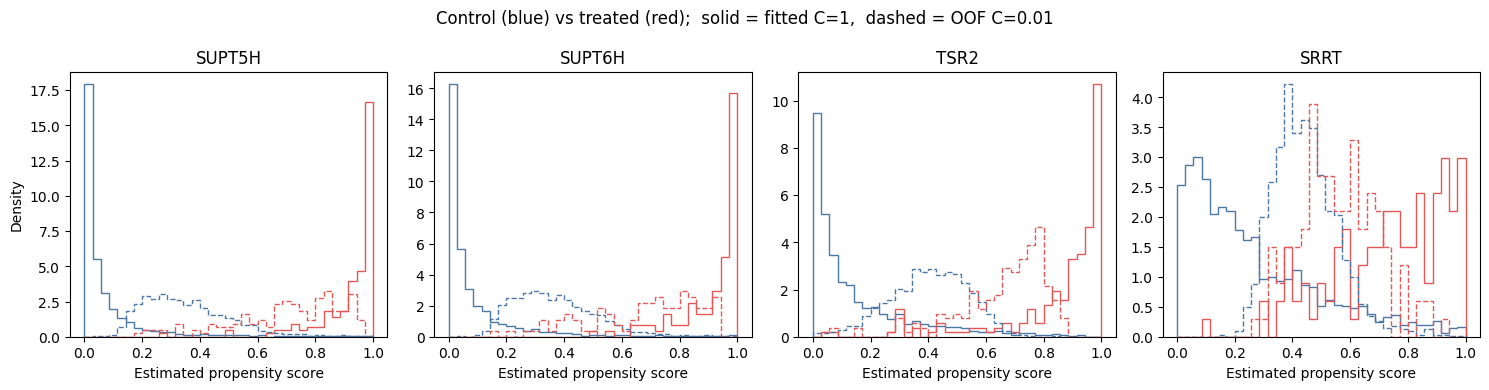

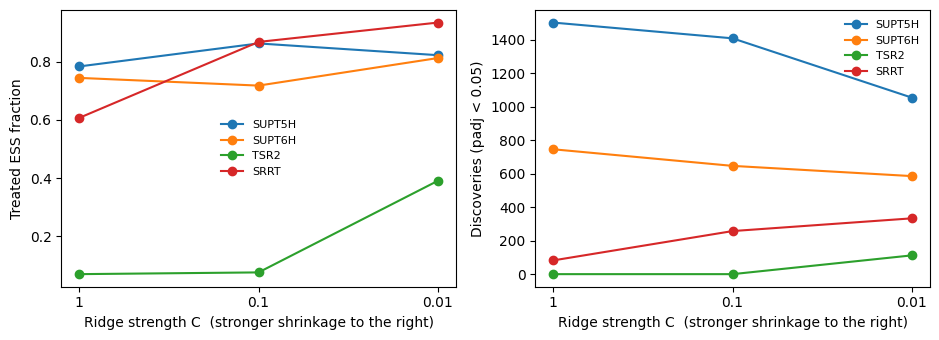

In [16]:
score_cache = np.load(ps_scores_path)
A_ps = score_cache['A']
ps_perturbations = score_cache['perturbations'].astype(str).tolist()
ps_control = A_ps.sum(axis=1) == 0

fig, axes = plt.subplots(1, 4, figsize=(15, 3.937), sharex=True)
for ax, perturbation in zip(axes, ps_focus):
    treated = A_ps[:, ps_perturbations.index(perturbation)] == 1
    for model, style in [('fitted balanced C=1', '-'), ('OOF balanced C=0.01', '--')]:
        scores = score_cache[f'{model}__{perturbation}']
        ax.hist(scores[ps_control], bins=35, range=(0, 1), density=True,
                histtype='step', color='#4c78a8', linestyle=style)
        ax.hist(scores[treated], bins=35, range=(0, 1), density=True,
                histtype='step', color='#e45756', linestyle=style)
    ax.set_title(perturbation)
    ax.set_xlabel('Estimated propensity score')
axes[0].set_ylabel('Density')
fig.suptitle('Control (blue) vs treated (red);  solid = fitted C=1,  dashed = OOF C=0.01')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5))
for perturbation in ps_focus:
    row = (grid[grid['treatment'] == perturbation]
           .set_index('C').reindex(ridge_order))
    axes[0].plot(ridge_order, row['ess_treated_fraction'], marker='o', label=perturbation)
    axes[1].plot(ridge_order, row['discoveries'], marker='o', label=perturbation)
axes[0].set_ylabel('Treated ESS fraction')
axes[1].set_ylabel(f'Discoveries (padj < {FDR})')
for ax in axes:
    ax.set_xlabel('Ridge strength C  (stronger shrinkage to the right)')
    ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

#### Reading the diagnostics

**Overlap is weak for the strongest perturbations.** At `C=1` only 5.6% of the SUPT5H
score distributions overlap, and 9.6% for SUPT6H. Both perturbations are easy to predict
from the latent factors, so the propensity model tells treated and control cells apart
almost perfectly.

**Stronger shrinkage always improves overlap, but only sometimes improves power.**

- **SUPT5H and SUPT6H** already keep most of their treated cells (ESS 78% and 74%), so
  extra shrinkage only adds bias: discoveries fall from 1,501 to 1,053 and from 745 to 585.
- **TSR2 is the opposite case.** At `C=1` its treated ESS is just 7%, meaning the estimate
  rests on a handful of cells; standard errors inflate 4.4× and it reports **no discoveries
  at all**. At `C=0.01` its ESS reaches 39% and 112 discoveries appear.

**So watch the treated ESS, not the discovery count.** When ESS collapses, that treatment
is being carried by too few cells and more shrinkage helps. When ESS is already healthy,
leave `C` alone — shrinking it further just trades power for smoother scores.

Because the best choice differs from treatment to treatment, causarray can refit only the
treatments you name, reusing the cached outcome predictions:

```python
pi_tuned, audit = refit_propensity_scores(
    A, W_A, pi_hat=estimation['pi_hat_raw'],
    drop_by_treatment={'TSR2': []},   # refit TSR2 alone, keeping every covariate
    C=0.01, K=5,
)
tuned_results, _ = LFC(Y, W, A, W_A, Y_hat=estimation['Y_hat'], pi_hat=pi_tuned)
```

Calibrated probabilities (`class_weight=None`) and stronger clipping also raise ESS, but
they inflate standard errors 2.3–10.4× here, so neither replaces choosing `C`.

## 6. Summary

- `gcate_lfc_batch` scales causarray to 200 perturbations by pairing batches of 15 with a
  shared control pool, yielding 20,450 significant gene × perturbation pairs at 5% FDR
  (median 24 per perturbation).
- A marginal Wilcoxon test reports about 19× more hits. Direction-specific GO enrichment
  favours the causarray lists as the more coherent ones, but discovery counts alone cannot
  decide which method is right.
- `align_test_mask` attaches expression-support rules to an existing result table by
  label, so such diagnostics never require refitting the LFC.
- Propensity overlap is weak for the strongest perturbations, and the best ridge strength
  differs by treatment. Watch the treated ESS, and use `refit_propensity_scores` to tune
  one treatment at a time without disturbing the rest.